# Customer Service Request AnalysisThis project analyzes NYC 311 service request data to identify patterns in complaints, response times, and city-wise distribution.

## Objectives- Analyze dataset- Clean and preprocess data- Visualize complaint patterns- Perform statistical analysis- Generate insights

In [1]:
# Importing Libraries

## Step 1: Import Libraries We import all required libraries for data analysis and visualization.

In [2]:
print("\n" + "="*80)
print("IMPORTING LIBRARIES...")
print("="*80)



IMPORTING LIBRARIES...


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)



In [5]:
print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Step 2: Data Loading and Exploration We load the dataset and inspect its structure.

In [27]:
print("\n" + "="*80)
print("STEP 2 : LOADING AND EXPLORING DATA")
print("="*80)



STEP 2 : LOADING AND EXPLORING DATA


In [7]:
# Load the CSV file
print("\nLoading CSV file...")
df = pd.read_csv("C:/Users/aashi/OneDrive/Desktop/NYC-311-Analysis/311_Service_Requests_from_2010_to_Present.csv")
print(f"✓ Loaded {len(df):,} records with {len(df.columns)} columns")


Loading CSV file...
✓ Loaded 364,558 records with 53 columns


In [8]:
# Display basic info
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")


Dataset shape: (364558, 53)

First 5 rows:
   Unique Key            Created Date             Closed Date Agency  \
0    32310363  12/31/2015 11:59:45 PM  01/01/2016 12:55:15 AM   NYPD   
1    32309934  12/31/2015 11:59:44 PM  01/01/2016 01:26:57 AM   NYPD   
2    32309159  12/31/2015 11:59:29 PM  01/01/2016 04:51:03 AM   NYPD   
3    32305098  12/31/2015 11:57:46 PM  01/01/2016 07:43:13 AM   NYPD   
4    32306529  12/31/2015 11:56:58 PM  01/01/2016 03:24:42 AM   NYPD   

                       Agency Name           Complaint Type  \
0  New York City Police Department  Noise - Street/Sidewalk   
1  New York City Police Department         Blocked Driveway   
2  New York City Police Department         Blocked Driveway   
3  New York City Police Department          Illegal Parking   
4  New York City Police Department          Illegal Parking   

                     Descriptor    Location Type  Incident Zip  \
0              Loud Music/Party  Street/Sidewalk       10034.0   
1           

In [9]:
# Check null values
print(f"\nNull values summary:")
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100
null_df = pd.DataFrame({
    'Column': null_counts.index,
    'Null_Count': null_counts.values,
    'Percentage': null_pct.values
})
null_df = null_df[null_df['Null_Count'] > 0].sort_values('Null_Count', ascending=False)
print(null_df.to_string(index=False))


Null values summary:
                        Column  Null_Count  Percentage
  School or Citywide Complaint      364558  100.000000
                  Vehicle Type      364558  100.000000
          Taxi Company Borough      364558  100.000000
         Taxi Pick Up Location      364558  100.000000
               Garage Lot Name      364558  100.000000
               Ferry Direction      364557   99.999726
           Ferry Terminal Name      364556   99.999451
        Bridge Highway Segment      364296   99.928132
                     Road Ramp      364296   99.928132
      Bridge Highway Direction      364261   99.918531
           Bridge Highway Name      364261   99.918531
                      Landmark      364183   99.897136
         Intersection Street 2      314046   86.144317
         Intersection Street 1      313438   85.977540
                Cross Street 2       57805   15.856187
                Cross Street 1       57188   15.686941
                   Street Name       51699 

## Step 3: Data Cleaning We handle missing values and fix incorrect data.

In [28]:
print("\n" + "="*80)
print("STEP 3 : DATA CLEANING")
print("="*80)



STEP 3 : DATA CLEANING


In [11]:
initial_count = len(df)

# Remove null Closed Date
print("\nRemoving records with null Closed Date...")
df = df[df['Closed Date'].notna()]
print(f"✓ Removed {initial_count - len(df):,} records")

# Convert dates
print("\nConverting date columns...")
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')

# Remove invalid timelines (Closed before Created)
print("Removing records with invalid timeline (Closed < Created)...")
initial_valid = len(df)
df = df[(df['Closed Date'] >= df['Created Date'])].copy()
print(f"✓ Removed {initial_valid - len(df):,} records")

# Calculate closing time in seconds
print("\nCalculating Request_Closing_Time...")
df['Request_Closing_Time'] = (df['Closed Date'] - df['Created Date']).dt.total_seconds()
df['Request_Closing_Time_Hours'] = df['Request_Closing_Time'] / 3600

print(f"Average closing time: {df['Request_Closing_Time_Hours'].mean():.2f} hours")
print(f"Median closing time: {df['Request_Closing_Time_Hours'].median():.2f} hours")

# Impute missing cities
print("\nHandling missing City values...")
null_cities = df['City'].isnull().sum()
df['City'] = df['City'].fillna('Unknown City')
print(f"✓ Imputed {null_cities:,} missing city values")

print(f"\n✓ Data cleaning complete!")
print(f"Final dataset: {len(df):,} records")



Removing records with null Closed Date...
✓ Removed 2,381 records

Converting date columns...
Removing records with invalid timeline (Closed < Created)...
✓ Removed 0 records

Calculating Request_Closing_Time...
Average closing time: 4.20 hours
Median closing time: 2.67 hours

Handling missing City values...
✓ Imputed 674 missing city values

✓ Data cleaning complete!
Final dataset: 362,177 records


## Step 4: Data VisualizationWe create graphs to understand patterns in complaints.

In [29]:
print("\n" + "="*80)
print("STEP 4 : DATA VISUALIZATION")
print("="*80)



STEP 4 : DATA VISUALIZATION


In [13]:
# Visualization 1: Null values frequency
print("\n1. Creating null values frequency plot...")
plt.figure(figsize=(14, 8))
null_counts_all = df.isnull().sum()
null_counts_all = null_counts_all[null_counts_all > 0].sort_values(ascending=False)
plt.barh(range(len(null_counts_all)), null_counts_all.values, color='coral')
plt.yticks(range(len(null_counts_all)), null_counts_all.index)
plt.xlabel('Number of Null Values')
plt.title('Null Values Distribution')
plt.tight_layout()
plt.savefig('01_null_values_frequency.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: 01_null_values_frequency.png")


1. Creating null values frequency plot...
✓ Saved: 01_null_values_frequency.png


In [14]:
# Visualization 2: Complaints by City
print("2. Creating complaints by city plot...")
city_counts = df['City'].value_counts().head(15)
plt.figure(figsize=(14, 8))
city_counts.plot(kind='bar', color='steelblue')
plt.title('Top 15 Cities with Most Complaints')
plt.xlabel('City')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('02_complaints_by_city.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: 02_complaints_by_city.png")



2. Creating complaints by city plot...
✓ Saved: 02_complaints_by_city.png


In [15]:
# Visualization 3: Brooklyn distribution
print("3. Creating Brooklyn spatial plots...")
brooklyn_df = df[df['City'] == 'BROOKLYN']
brooklyn_coords = brooklyn_df[['Latitude', 'Longitude']].dropna()

if len(brooklyn_coords) > 100:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter
    axes[0].scatter(brooklyn_coords['Longitude'], brooklyn_coords['Latitude'],
                   alpha=0.5, s=10, color='blue')
    axes[0].set_title('Scatter: Complaints in Brooklyn')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    
    # Hexbin
    axes[1].hexbin(brooklyn_coords['Longitude'], brooklyn_coords['Latitude'],
                  gridsize=30, cmap='YlOrRd', mincnt=1)
    axes[1].set_title('Hexbin: Complaint Concentration in Brooklyn')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    
    plt.tight_layout()
    plt.savefig('03_brooklyn_complaint_distribution.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✓ Saved: 03_brooklyn_complaint_distribution.png")
else:
    print("⚠ Insufficient Brooklyn data for spatial plots")

3. Creating Brooklyn spatial plots...
✓ Saved: 03_brooklyn_complaint_distribution.png


In [16]:
# Visualization 4: Complaint types
print("4. Creating complaint types plot...")
complaint_counts = df['Complaint Type'].value_counts()
plt.figure(figsize=(14, 8))
complaint_counts.head(15).plot(kind='bar', color='teal')
plt.title('Top 15 Types of Complaints')
plt.xlabel('Complaint Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('04_complaint_types.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: 04_complaint_types.png")



4. Creating complaint types plot...
✓ Saved: 04_complaint_types.png


In [17]:
# Visualization 5: Complaints by city stacked
print("5. Creating complaints by city stacked plot...")
top_cities = df['City'].value_counts().head(5).index
top_complaints = df['Complaint Type'].value_counts().head(8).index
df_filtered = df[(df['City'].isin(top_cities)) & (df['Complaint Type'].isin(top_complaints))]
city_complaint = pd.crosstab(df_filtered['City'], df_filtered['Complaint Type'])

plt.figure(figsize=(14, 8))
city_complaint.plot(kind='bar', figsize=(14, 8), colormap='tab20')
plt.title('Complaint Distribution by City')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Complaint Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('05_complaints_by_city_stacked.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: 05_complaints_by_city_stacked.png")



5. Creating complaints by city stacked plot...
✓ Saved: 05_complaints_by_city_stacked.png


<Figure size 1400x800 with 0 Axes>

In [18]:
# Visualization 6: Average closing time
print("6. Creating average closing time plot...")
avg_closing = df.groupby('Complaint Type')['Request_Closing_Time_Hours'].mean().sort_values(ascending=False)
plt.figure(figsize=(14, 8))
avg_closing.head(15).plot(kind='barh', color='coral')
plt.title('Average Closing Time by Complaint Type')
plt.xlabel('Hours')
plt.tight_layout()
plt.savefig('06_avg_closing_time_by_complaint.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: 06_avg_closing_time_by_complaint.png")

6. Creating average closing time plot...
✓ Saved: 06_avg_closing_time_by_complaint.png


7. Creating comprehensive response time analysis...


Text(0.5, 0, 'Hours')

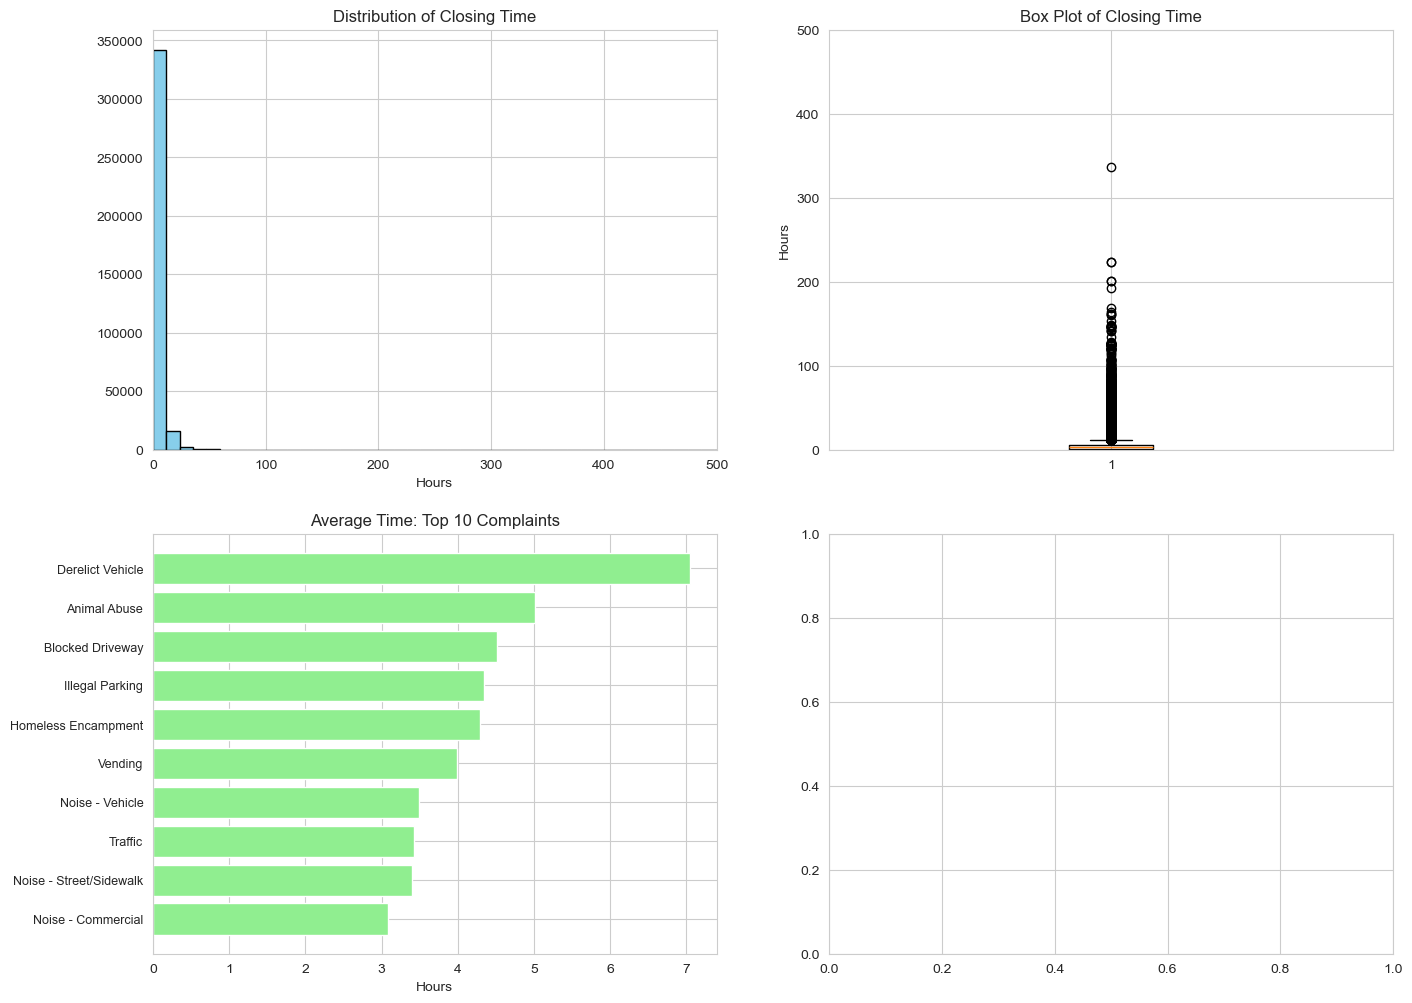

In [19]:
# Visualization 7: Response time analysis (comprehensive)
print("7. Creating comprehensive response time analysis...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution
axes[0, 0].hist(df['Request_Closing_Time_Hours'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Closing Time')
axes[0, 0].set_xlabel('Hours')
axes[0, 0].set_xlim(0, 500)

# Box plot
axes[0, 1].boxplot(df['Request_Closing_Time_Hours'], vert=True)
axes[0, 1].set_title('Box Plot of Closing Time')
axes[0, 1].set_ylabel('Hours')
axes[0, 1].set_ylim(0, 500)

# Average by top complaints
top_10 = complaint_counts.head(10)
avg_by_complaint = df[df['Complaint Type'].isin(top_10.index)].groupby('Complaint Type')['Request_Closing_Time_Hours'].mean().sort_values()
axes[1, 0].barh(range(len(avg_by_complaint)), avg_by_complaint.values, color='lightgreen')
axes[1, 0].set_yticks(range(len(avg_by_complaint)))
axes[1, 0].set_yticklabels(avg_by_complaint.index, fontsize=9)
axes[1, 0].set_title('Average Time: Top 10 Complaints')
axes[1, 0].set_xlabel('Hours')

In [20]:
# Summary stats
axes[1, 1].axis('off')
stats_text = f"""SUMMARY STATISTICS

Mean: {df['Request_Closing_Time_Hours'].mean():.2f} hrs
Median: {df['Request_Closing_Time_Hours'].median():.2f} hrs
Std Dev: {df['Request_Closing_Time_Hours'].std():.2f} hrs
Min: {df['Request_Closing_Time_Hours'].min():.2f} hrs
Max: {df['Request_Closing_Time_Hours'].max():.2f} hrs

Total Records: {len(df):,}
Unique Complaints: {df['Complaint Type'].nunique()}
Unique Cities: {df['City'].nunique()}
"""

axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('07_response_time_analysis.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: 07_response_time_analysis.png")



✓ Saved: 07_response_time_analysis.png


In [21]:
print("\n✓ All visualizations created!")


✓ All visualizations created!


## Step 5: Statistical Analysis We apply hypothesis testing using Kruskal-Wallis test.

In [30]:
print("\n" + "="*80)
print("STEP 5 : STATISTICAL ANALYSIS")
print("="*80)



STEP 5 : STATISTICAL ANALYSIS


In [26]:
# Kruskal-Wallis test for complaint types
print("\nKruskal-Wallis H Test: Complaint Types")
print("-" * 80)
print("H0: All complaint types have equal distribution of closing times")
print("H1: At least one complaint type differs")
print(f"Significance Level (α): 0.05")

top_complaints_test = df['Complaint Type'].value_counts().head(10).index
groups = []
for complaint in top_complaints_test:
    group_data = df[df['Complaint Type'] == complaint]['Request_Closing_Time'].dropna()
    if len(group_data) > 0:
        groups.append(group_data.values)

h_stat, p_val = stats.kruskal(*groups)

print(f"\nResults:")
print(f"  H-statistic: {h_stat:.6f}")
print(f"  P-value: {p_val:.10f}")

if p_val < 0.05:
    print(f"\n✓ REJECT H0 (p < 0.05)")
    print("  Conclusion: Complaint types have SIGNIFICANTLY DIFFERENT closing times")
else:
    print(f"\n✓ FAIL TO REJECT H0 (p ≥ 0.05)")
    print("  Conclusion: Complaint types have similar closing times")

# Kruskal-Wallis test for cities
print("\n" + "-" * 80)
print("Kruskal-Wallis H Test: Cities")
print("-" * 80)

top_cities_test = df['City'].value_counts().head(5).index
city_groups = []
for city in top_cities_test:
    city_data = df[df['City'] == city]['Request_Closing_Time'].dropna()
    if len(city_data) > 0:
        city_groups.append(city_data.values)

h_stat_city, p_val_city = stats.kruskal(*city_groups)

print(f"\nResults:")
print(f"  H-statistic: {h_stat_city:.6f}")
print(f"  P-value: {p_val_city:.10f}")

if p_val_city < 0.05:
    print(f"\n✓ REJECT H0 (p < 0.05)")
    print("  Conclusion: Cities have SIGNIFICANTLY DIFFERENT closing times")
else:
    print(f"\n✓ FAIL TO REJECT H0 (p ≥ 0.05)")
    print("  Conclusion: Cities have similar closing times")


Kruskal-Wallis H Test: Complaint Types
--------------------------------------------------------------------------------
H0: All complaint types have equal distribution of closing times
H1: At least one complaint type differs
Significance Level (α): 0.05

Results:
  H-statistic: 11331.577205
  P-value: 0.0000000000

✓ REJECT H0 (p < 0.05)
  Conclusion: Complaint types have SIGNIFICANTLY DIFFERENT closing times

--------------------------------------------------------------------------------
Kruskal-Wallis H Test: Cities
--------------------------------------------------------------------------------

Results:
  H-statistic: 14352.375869
  P-value: 0.0000000000

✓ REJECT H0 (p < 0.05)
  Conclusion: Cities have SIGNIFICANTLY DIFFERENT closing times


## Step 6: Key Insinghts That will help us to summarize the scenario.

In [31]:
print("\n" + "="*80)
print("STEP 6 : KEY INSIGHTS")
print("="*80)



STEP 6 : KEY INSIGHTS


In [32]:
print("\n1. DATA QUALITY:")
print(f"   - Initial records: {initial_count:,}")
print(f"   - Final records: {len(df):,}")
print(f"   - Records removed: {initial_count - len(df):,}")


1. DATA QUALITY:
   - Initial records: 364,558
   - Final records: 362,177
   - Records removed: 2,381


In [33]:
print("\n2. TOP COMPLAINT TYPES:")
for i, (complaint, count) in enumerate(complaint_counts.head(5).items(), 1):
    pct = (count / len(df)) * 100
    print(f"   {i}. {complaint}: {count:,} ({pct:.1f}%)")


2. TOP COMPLAINT TYPES:
   1. Blocked Driveway: 100,624 (27.8%)
   2. Illegal Parking: 91,716 (25.3%)
   3. Noise - Street/Sidewalk: 51,139 (14.1%)
   4. Noise - Commercial: 43,751 (12.1%)
   5. Derelict Vehicle: 21,518 (5.9%)


In [34]:
print("\n3. TOP CITIES:")
for i, (city, count) in enumerate(city_counts.head(5).items(), 1):
    pct = (count / len(df)) * 100
    print(f"   {i}. {city}: {count:,} ({pct:.1f}%)")


3. TOP CITIES:
   1. BROOKLYN: 118,849 (32.8%)
   2. NEW YORK: 77,289 (21.3%)
   3. BRONX: 49,166 (13.6%)
   4. STATEN ISLAND: 15,335 (4.2%)
   5. JAMAICA: 8,930 (2.5%)


In [35]:
print("\n4. CLOSING TIME INSIGHTS:")
print(f"   - Average: {df['Request_Closing_Time_Hours'].mean():.2f} hours")
print(f"   - Median: {df['Request_Closing_Time_Hours'].median():.2f} hours")
print(f"   - Range: {df['Request_Closing_Time_Hours'].min():.2f} to {df['Request_Closing_Time_Hours'].max():.2f} hours")


4. CLOSING TIME INSIGHTS:
   - Average: 4.20 hours
   - Median: 2.67 hours
   - Range: 0.02 to 592.87 hours


In [36]:
print("\n5. STATISTICAL SIGNIFICANCE:")
print(f"   - Complaint types differ: {p_val < 0.05}")
print(f"   - Cities differ: {p_val_city < 0.05}")


5. STATISTICAL SIGNIFICANCE:
   - Complaint types differ: True
   - Cities differ: True


## Step 6: Summarizing the Analysis.

In [37]:
print("\n" + "="*80)
print("STEP 6 : SAVING SUMMARY")
print("="*80)


STEP 6 : SAVING SUMMARY


In [38]:
summary_data = {
    'Metric': [
        'Total Records',
        'Unique Complaints',
        'Unique Cities',
        'Avg Closing Time (hours)',
        'Median Closing Time (hours)',
        'Max Closing Time (hours)',
        'Data Start Date',
        'Data End Date'
    ],
    'Value': [
        f"{len(df):,}",
        df['Complaint Type'].nunique(),
        df['City'].nunique(),
        f"{df['Request_Closing_Time_Hours'].mean():.2f}",
        f"{df['Request_Closing_Time_Hours'].median():.2f}",
        f"{df['Request_Closing_Time_Hours'].max():.2f}",
        str(df['Created Date'].min().date()),
        str(df['Created Date'].max().date())
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('analysis_summary.csv', index=False)

print("\n✓ Saved: analysis_summary.csv")
print("\nSummary:")
print(summary_df.to_string(index=False))


✓ Saved: analysis_summary.csv

Summary:
                     Metric      Value
              Total Records    362,177
          Unique Complaints         23
              Unique Cities         54
   Avg Closing Time (hours)       4.20
Median Closing Time (hours)       2.67
   Max Closing Time (hours)     592.87
            Data Start Date 2015-01-01
              Data End Date 2015-12-31


## Step 7 : Saving the Results

In [39]:
print("\n" + "="*80)
print("STep 7 : ANALYSIS COMPLETE")
print("="*80)

print("\nGenerated Files:")
print("  - 01_null_values_frequency.png")
print("  - 02_complaints_by_city.png")
print("  - 03_brooklyn_complaint_distribution.png")
print("  - 04_complaint_types.png")
print("  - 05_complaints_by_city_stacked.png")
print("  - 06_avg_closing_time_by_complaint.png")
print("  - 07_response_time_analysis.png")
print("  - analysis_summary.csv")


STep 7 : ANALYSIS COMPLETE

Generated Files:
  - 01_null_values_frequency.png
  - 02_complaints_by_city.png
  - 03_brooklyn_complaint_distribution.png
  - 04_complaint_types.png
  - 05_complaints_by_city_stacked.png
  - 06_avg_closing_time_by_complaint.png
  - 07_response_time_analysis.png
  - analysis_summary.csv


## Conclusion The analysis highlights complaint trends, city distribution, and response time variations.